In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers

In [ ]:
!pip install -q datasets jiwer

In [ ]:
import pandas as pd

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])

# Ensure file extensions are correct
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])

test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Display sample data
print(train_df.head(), test_df.head())



  file_name        text
0  0255.png          of
1  0254.png         air
2  0250.png  documented
3  0224.png          an
4  0265.png         the   file_name       text
0  0245.png        and
1  0256.png    written
2  0232.png         up
3  0251.png        and
4  0266.png  Thirties.


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # prepare image (i.e. resize + normalize)
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(0), "labels": torch.tensor(labels)}
        return encoding


initialize the training and evaluation datasets:

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor
import torch

class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get file name and text
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # Prepare image (resize and normalize)
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze(0)

        # Add labels (encoded text)
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # Replace pad token ids with -100 so the loss function ignores them
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        # Tokenize the text for input_ids
        input_ids = self.processor.tokenizer(text,
                                            add_special_tokens=True,
                                            padding="max_length",
                                            max_length=self.max_target_length,
                                            truncation=True,
                                            return_tensors="pt").input_ids.squeeze(0)


        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(labels),
            "input_ids": input_ids # Add input_ids to the returned dictionary
        }

# Initialize processor
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

# Load datasets
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train/',
                              df=train_df,
                              processor=processor)

eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test/',
                             df=test_df,
                             processor=processor)


In [ ]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

Number of training examples: 222
Number of validation examples: 47


verify an example from the training dataset:

pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])
input_ids torch.Size([128])


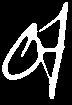

In [ ]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)
image = Image.open(train_dataset.root_dir + train_df['file_name'][0]).convert("RGB")
image



In [ ]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

of


TRAINING

In [ ]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

training arguments

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=200,
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
!pip install evaluate


In [ ]:
import evaluate

cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}


In [ ]:
from transformers import TrOCRProcessor

# Initialize the processor
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")


In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

# Initialize the data collator with padding for pixel_values
data_collator = DataCollatorForSeq2Seq(
    tokenizer=processor.tokenizer,  # Use tokenizer from processor
    model=model,
    label_pad_token_id=-100,  # Ensure padding labels are ignored in loss
    padding=True, # Enable padding
    pad_to_multiple_of=8 # Pad to a multiple of 8 for efficient computation
)

# Define the training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    num_train_epochs=3,
    predict_with_generate=True,
    logging_dir='./logs',
    fp16=True, # Enable mixed precision training if your GPU supports it
)

# Set up the trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,  # Use the updated data collator
    compute_metrics=compute_metrics, # Include compute_metrics function
)

# Start training
trainer.train()


ValueError: You should supply an encoding or a list of encodings to this method that includes input_ids, but you provided ['pixel_values']

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

# Initialize the data collator with padding for pixel_values
data_collator = DataCollatorForSeq2Seq(
    tokenizer=processor.tokenizer,  # Use tokenizer from processor
    model=model,
    label_pad_token_id=-100,  # Ensure padding labels are ignored in loss
    padding=True, # Enable padding
    pad_to_multiple_of=8 # Pad to a multiple of 8 for efficient computation
)

# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator, # Use DataCollatorForSeq2Seq
)
trainer.train()

ValueError: You should supply an encoding or a list of encodings to this method that includes input_ids, but you provided ['pixel_values']

RETRY

In [ ]:
!pip install -q transformers
!pip install -q datasets jiwer
!pip install evaluate

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
import evaluate

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])
test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

print(train_df.head(), test_df.head())

# Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")

        # Process image and text together
        encoding = self.processor(
            images=image,
            text=text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        )

        # Correctly access input_ids as labels
        labels = encoding["input_ids"].squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # Get attention mask
        attention_mask = encoding.get("attention_mask", torch.ones_like(labels))

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": labels,  # Correctly extracted from input_ids
            "attention_mask": attention_mask.squeeze(0)
        }



# Initialize Processor and Datasets
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train/', df=train_df, processor=processor)
eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test/', df=test_df, processor=processor)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(eval_dataset))

# Initialize Model
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

# Define Metrics
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    pred_texts = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    label_texts = processor.batch_decode(label_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_texts, references=label_texts)
    return {"cer": cer}

# Data Collator for Vision-Language Models
data_collator = DataCollatorForSeq2Seq(
    tokenizer=processor.tokenizer,
    model=model,
    label_pad_token_id=-100,
    padding=True
)

# Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    num_train_epochs=3,
    predict_with_generate=True,
    logging_dir='./logs',
    fp16=True
)

# Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Start Training
trainer.train()


  file_name        text
0  0255.png          of
1  0254.png         air
2  0250.png  documented
3  0224.png          an
4  0265.png         the   file_name       text
0  0245.png        and
1  0256.png    written
2  0232.png         up
3  0251.png        and
4  0266.png  Thirties.


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Training examples: 222
Validation examples: 47


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

KeyError: 'input_ids'

TRAINING WITH EPOCH 3

In [ ]:
!pip install -q transformers
!pip install -q datasets jiwer
!pip install evaluate
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers import default_data_collator
import evaluate

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])

# Ensure file extensions are correct
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])

test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)


# Define CustomDataset class
class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # prepare image (i.e. resize + normalize)
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(0), "labels": torch.tensor(labels)}
        return encoding

# Load the processor and model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-stage1")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

# Load datasets
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train', # Update with your actual paths
                              df=train_df,
                              processor=processor)

eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test', # Update with your actual paths
                             df=test_df,
                             processor=processor)

# Prepare your training arguments
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=200,
    remove_unused_columns=False,  # Ensure num_items_in_batch is not removed
)

# Define compute_metrics function
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

# Use processing_class for tokenization instead of the tokenizer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,  # Use the processor for tokenization
    data_collator=default_data_collator,  # Use a collator appropriate for your dataset
    compute_metrics=compute_metrics
)

# Remove 'num_items_in_batch' from the arguments passed to the model's forward method
class CustomTrainer(Seq2SeqTrainer):
    def training_step(self, model, inputs, num_items_in_batch=None):
        # Remove 'num_items_in_batch' from inputs
        inputs.pop("num_items_in_batch", None)
        return super().training_step(model, inputs)

# Use the custom trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 210115 (23024-tkm-college-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Step,Training Loss,Validation Loss


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 64, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=84, training_loss=1.8888422364280337, metrics={'train_runtime': 257.0147, 'train_samples_per_second': 2.591, 'train_steps_per_second': 0.327, 'total_flos': 5.893403701401354e+17, 'train_loss': 1.8888422364280337, 'epoch': 3.0})

In [ ]:
!pip install -q transformers
!pip install -q datasets jiwer
!pip install evaluate
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers import default_data_collator
import evaluate

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])

# Ensure file extensions are correct
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])

test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)


# Define CustomDataset class
class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # prepare image (i.e. resize + normalize)
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(0), "labels": torch.tensor(labels)}
        return encoding

# Load the processor and model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-stage1")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

# Load datasets
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train', # Update with your actual paths
                              df=train_df,
                              processor=processor)

eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test', # Update with your actual paths
                             df=test_df,
                             processor=processor)

# Prepare your training arguments
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=200,
    remove_unused_columns=False,  # Ensure num_items_in_batch is not removed
)

# Define compute_metrics function
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

# Use processing_class for tokenization instead of the tokenizer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,  # Use the processor for tokenization
    data_collator=default_data_collator,  # Use a collator appropriate for your dataset
    compute_metrics=compute_metrics
)

# Remove 'num_items_in_batch' from the arguments passed to the model's forward method
class CustomTrainer(Seq2SeqTrainer):
    def training_step(self, model, inputs, num_items_in_batch=None):
        # Remove 'num_items_in_batch' from inputs
        inputs.pop("num_items_in_batch", None)
        return super().training_step(model, inputs)

# Use the custom trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Step,Training Loss,Validation Loss


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 64, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=84, training_loss=1.910274515549342, metrics={'train_runtime': 129.3618, 'train_samples_per_second': 5.148, 'train_steps_per_second': 0.649, 'total_flos': 5.893403701401354e+17, 'train_loss': 1.910274515549342, 'epoch': 3.0})

In [ ]:
!pip install -q transformers
!pip install -q datasets jiwer
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers import default_data_collator
import evaluate

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])

# Ensure file extensions are correct
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])
test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)


# Define CustomDataset class
class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # prepare image (i.e. resize + normalize)
        image_path = f"{self.root_dir}/{file_name}"
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length,
                                          truncation=True).input_ids

        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(0), "labels": torch.tensor(labels)}
        return encoding

# Load the processor and model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-stage1")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

# Load datasets
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train', # Update with your actual paths
                              df=train_df,
                              processor=processor)

eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test', # Update with your actual paths
                             df=test_df,
                             processor=processor)

# Prepare your training arguments
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=200,
    remove_unused_columns=False,  # Ensure num_items_in_batch is not removed
    learning_rate=3e-5
)

# Define compute_metrics function
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

# Custom trainer to log training loss, validation loss, and CER at each step
class CustomTrainer(Seq2SeqTrainer):
    def on_log(self, logs):
        # Print logs containing training/validation loss and CER
        if 'loss' in logs:
            print(f"Training Loss: {logs['loss']}")
        if 'eval_loss' in logs:
            print(f"Validation Loss: {logs['eval_loss']}")
        if 'eval_cer' in logs:
            print(f"Validation CER: {logs['eval_cer']}")

    def training_step(self, model, inputs, num_items_in_batch=None):
        # Remove 'num_items_in_batch' from inputs
        inputs.pop("num_items_in_batch", None)
        return super().training_step(model, inputs)

# Use the custom trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()


RuntimeError: Failed to import transformers.models.trocr.processing_trocr because of the following error (look up to see its traceback):
partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)